In [1]:
# Cell 1: Import Required Libraries
import pandas as pd
import numpy as np
import joblib
import mlflow
import optuna
import json
import time
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, average_precision_score,
                           confusion_matrix, roc_curve, precision_recall_curve,
                           ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

print("✅ Libraries imported")

c:\Users\touhi\Desktop\ML Projects\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported


In [2]:
# Load Data and Preprocessor
# Load preprocessed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Load preprocessor and selector
preprocessor = joblib.load('../models/preprocessor.pkl')
selector = joblib.load('../models/selector.pkl')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Val fraud rate: {y_val.mean()*100:.2f}%")
print(f"Test fraud rate: {y_test.mean()*100:.2f}%")
print("\n✅ Data loaded")

Train: (7000, 47), Val: (1500, 47), Test: (1500, 47)
Train fraud rate: 6.10%
Val fraud rate: 7.13%
Test fraud rate: 5.93%

✅ Data loaded


In [3]:
# Apply Preprocessing to Data
print("Applying preprocessing...")
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_val_processed shape: {X_val_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print("✅ Preprocessing complete")

Applying preprocessing...
X_train_processed shape: (7000, 93)
X_val_processed shape: (1500, 93)
X_test_processed shape: (1500, 93)
✅ Preprocessing complete


In [4]:
# Evaluation Function
def evaluate_model(y_true, y_pred, y_pred_proba=None, model_name="Model"):
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }
    
    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
        metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba)
    
    return metrics

def print_metrics(metrics):
    print(f"\n{metrics['model']}:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    if 'roc_auc' in metrics:
        print(f"  ROC-AUC: {metrics['roc_auc']:.4f}")
    if 'pr_auc' in metrics:
        print(f"  PR-AUC: {metrics['pr_auc']:.4f}")
    
print("✅ Evaluation function defined")

✅ Evaluation function defined


In [5]:
# Baseline Model Development
print("=" * 60)
print("BASELINE MODEL DEVELOPMENT")
print("=" * 60)

baseline_results = []

#  Dummy Classifiers
print("\n1️⃣ Training Dummy Classifiers...")
dummy_stratified = DummyClassifier(strategy='stratified', random_state=42)
dummy_stratified.fit(X_train_processed, y_train)
y_pred_dummy_strat = dummy_stratified.predict(X_val_processed)

dummy_most_freq = DummyClassifier(strategy='most_frequent')
dummy_most_freq.fit(X_train_processed, y_train)
y_pred_dummy_freq = dummy_most_freq.predict(X_val_processed)

dummy_uniform = DummyClassifier(strategy='uniform', random_state=42)
dummy_uniform.fit(X_train_processed, y_train)
y_pred_dummy_uniform = dummy_uniform.predict(X_val_processed)

baseline_results.append(evaluate_model(y_val, y_pred_dummy_strat, model_name="Dummy_Stratified"))
baseline_results.append(evaluate_model(y_val, y_pred_dummy_freq, model_name="Dummy_MostFreq"))
baseline_results.append(evaluate_model(y_val, y_pred_dummy_uniform, model_name="Dummy_Uniform"))

print("   ✅ Dummy classifiers complete")

#  Logistic Regression with class_weight='balanced'
print("\n2️⃣ Training Logistic Regression...")
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_val_processed)
y_pred_proba_lr = lr.predict_proba(X_val_processed)[:, 1]
baseline_results.append(evaluate_model(y_val, y_pred_lr, y_pred_proba_lr, "LogisticRegression"))
print("   ✅ Logistic Regression complete")

#  Random Forest with class_weight='balanced'
print("\n3️⃣ Training Random Forest...")
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_val_processed)
y_pred_proba_rf = rf.predict_proba(X_val_processed)[:, 1]
baseline_results.append(evaluate_model(y_val, y_pred_rf, y_pred_proba_rf, "RandomForest"))
print("   ✅ Random Forest complete")

#  XGBoost with scale_pos_weight
print("\n4️⃣ Training XGBoost...")
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_val_processed)
y_pred_proba_xgb = xgb_model.predict_proba(X_val_processed)[:, 1]
baseline_results.append(evaluate_model(y_val, y_pred_xgb, y_pred_proba_xgb, "XGBoost"))
print("   ✅ XGBoost complete")

#  LightGBM with class_weight='balanced'
print("\n5️⃣ Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_processed, y_train)
y_pred_lgb = lgb_model.predict(X_val_processed)
y_pred_proba_lgb = lgb_model.predict_proba(X_val_processed)[:, 1]
baseline_results.append(evaluate_model(y_val, y_pred_lgb, y_pred_proba_lgb, "LightGBM"))
print("   ✅ LightGBM complete")

#  CatBoost with class_weights
print("\n6️⃣ Training CatBoost...")
catboost_model = CatBoostClassifier(
    class_weights=[1, scale_pos_weight],
    iterations=100,
    random_state=42,
    verbose=False
)
catboost_model.fit(X_train_processed, y_train)
y_pred_cat = catboost_model.predict(X_val_processed)
y_pred_proba_cat = catboost_model.predict_proba(X_val_processed)[:, 1]
baseline_results.append(evaluate_model(y_val, y_pred_cat, y_pred_proba_cat, "CatBoost"))
print("   ✅ CatBoost complete")

BASELINE MODEL DEVELOPMENT

1️⃣ Training Dummy Classifiers...
   ✅ Dummy classifiers complete

2️⃣ Training Logistic Regression...
   ✅ Logistic Regression complete

3️⃣ Training Random Forest...
   ✅ Random Forest complete

4️⃣ Training XGBoost...
   ✅ XGBoost complete

5️⃣ Training LightGBM...
   ✅ LightGBM complete

6️⃣ Training CatBoost...
   ✅ CatBoost complete


In [6]:
# Baseline Results Comparison
print("\n" + "=" * 60)
print("BASELINE MODEL COMPARISON")
print("=" * 60)

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df.to_string(index=False))

best_baseline_f1 = baseline_df.loc[baseline_df['f1'].idxmax()]
print(f"\n✅ Best Baseline Model (F1): {best_baseline_f1['model']} (F1: {best_baseline_f1['f1']:.4f})")

baseline_df.to_csv('../models/baseline_results.csv', index=False)
print("\n✅ Baseline results saved to ../models/baseline_results.csv")


BASELINE MODEL COMPARISON
             model  accuracy  precision   recall       f1  roc_auc   pr_auc
  Dummy_Stratified  0.873333   0.080808 0.074766 0.077670      NaN      NaN
    Dummy_MostFreq  0.928667   0.000000 0.000000 0.000000      NaN      NaN
     Dummy_Uniform  0.501333   0.070950 0.495327 0.124122      NaN      NaN
LogisticRegression  0.970000   0.715278 0.962617 0.820717 0.989990 0.938067
      RandomForest  0.984000   0.936842 0.831776 0.881188 0.988460 0.943924
           XGBoost  0.981333   0.862385 0.878505 0.870370 0.993365 0.948584
          LightGBM  0.988000   0.940594 0.887850 0.913462 0.993519 0.947379
          CatBoost  0.981333   0.862385 0.878505 0.870370 0.993412 0.935501

✅ Best Baseline Model (F1): LightGBM (F1: 0.9135)

✅ Baseline results saved to ../models/baseline_results.csv


In [7]:
# Hyperparameter Tuning with Optuna
print("\n" + "=" * 60)
print(" HYPERPARAMETER TUNING WITH OPTUNA")
print("=" * 60)

def objective_xgb(trial, X_train, y_train, X_val, y_val):
    """Optuna objective for XGBoost"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight': (len(y_train) - y_train.sum()) / y_train.sum()
    }
    
    model = xgb.XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss')
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val_cv = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_cv = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred_cv = model.predict_proba(X_val_cv)[:, 1]
        cv_scores.append(roc_auc_score(y_val_cv, y_pred_cv))
    
    return np.mean(cv_scores)

def objective_lgb(trial, X_train, y_train, X_val, y_val):
    """Optuna objective for LightGBM"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'class_weight': 'balanced'
    }
    
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val_cv = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_cv = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred_cv = model.predict_proba(X_val_cv)[:, 1]
        cv_scores.append(roc_auc_score(y_val_cv, y_pred_cv))
    
    return np.mean(cv_scores)

# Run Optuna for top 2 models from baseline
print("\n🔍 Running Optuna optimization for XGBoost...")
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(lambda trial: objective_xgb(trial, X_train_processed, y_train, X_val_processed, y_val), 
                   n_trials=20, show_progress_bar=True)

print("\n🔍 Running Optuna optimization for LightGBM...")
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lambda trial: objective_lgb(trial, X_train_processed, y_train, X_val_processed, y_val), 
                   n_trials=20, show_progress_bar=True)

print("\n✅ Optuna optimization complete")
print(f"Best XGBoost AUC: {study_xgb.best_value:.4f}")
print(f"Best LightGBM AUC: {study_lgb.best_value:.4f}")

joblib.dump(study_xgb.best_params, '../models/best_params_xgb.pkl')
joblib.dump(study_lgb.best_params, '../models/best_params_lgb.pkl')

[I 2026-08-10 10:08:19,753] A new study created in memory with name: no-name-ec2c0323-dca7-4f60-bca9-99c6a70daac1



 HYPERPARAMETER TUNING WITH OPTUNA

🔍 Running Optuna optimization for XGBoost...


Best trial: 0. Best value: 0.996419:   5%|▌         | 1/20 [00:01<00:34,  1.83s/it]

[I 2026-08-10 10:08:21,580] Trial 0 finished with value: 0.9964187966707879 and parameters: {'n_estimators': 144, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.9964187966707879.


Best trial: 0. Best value: 0.996419:  10%|█         | 2/20 [00:03<00:26,  1.45s/it]

...

Best trial: 16. Best value: 0.996828:  95%|█████████▌| 19/20 [00:14<00:00,  1.19it/s]

[I 2026-08-10 10:09:02,746] Trial 18 finished with value: 0.9954458836697958 and parameters: {'n_estimators': 101, 'max_depth': 4, 'learning_rate': 0.027084622450187633, 'num_leaves': 71, 'subsample': 0.8750273995162666, 'colsample_bytree': 0.7750252542034568, 'min_child_samples': 24, 'reg_alpha': 0.4159001355600754, 'reg_lambda': 0.14593587978127986}. Best is trial 16 with value: 0.9968280380915938.


Best trial: 16. Best value: 0.996828: 100%|██████████| 20/20 [00:15<00:00,  1.30it/s]

[I 2026-08-10 10:09:03,645] Trial 19 finished with value: 0.9962401440824694 and parameters: {'n_estimators': 180, 'max_depth': 7, 'learning_rate': 0.02506708133924297, 'num_leaves': 49, 'subsample': 0.9853645720178599, 'colsample_bytree': 0.6994057339199546, 'min_child_samples': 26, 'reg_alpha': 0.21592338589650675, 'reg_lambda': 0.28010947973660216}. Best is trial 16 with value: 0.9968280380915938.

✅ Optuna optimization complete
Best XGBoost AUC: 0.9967
Best LightGBM AUC: 0.9968


['../models/best_params_lgb.pkl']

In [8]:
# Train Optimized Models
print("\n" + "=" * 60)
print("TRAINING OPTIMIZED MODELS")
print("=" * 60)

# Train optimized XGBoost
print("\n🔧 Training Optimized XGBoost...")
xgb_opt_params = study_xgb.best_params.copy()
xgb_opt_params['scale_pos_weight'] = (len(y_train) - y_train.sum()) / y_train.sum()
xgb_opt_params['random_state'] = 42
xgb_opt_params['use_label_encoder'] = False
xgb_opt_params['eval_metric'] = 'logloss'

xgb_opt = xgb.XGBClassifier(**xgb_opt_params)
xgb_opt.fit(X_train_processed, y_train)
print("   ✅ Optimized XGBoost trained")

# Train optimized LightGBM
print("\n🔧 Training Optimized LightGBM...")
lgb_opt_params = study_lgb.best_params.copy()
lgb_opt_params['random_state'] = 42
lgb_opt_params['verbose'] = -1
lgb_opt_params['class_weight'] = 'balanced'

lgb_opt = lgb.LGBMClassifier(**lgb_opt_params)
lgb_opt.fit(X_train_processed, y_train)
print("   ✅ Optimized LightGBM trained")


TRAINING OPTIMIZED MODELS

🔧 Training Optimized XGBoost...
   ✅ Optimized XGBoost trained

🔧 Training Optimized LightGBM...
   ✅ Optimized LightGBM trained


In [9]:
# Evaluate Optimized Models
print("\n" + "=" * 60)
print("OPTIMIZED MODEL EVALUATION")
print("=" * 60)

optimized_results = []

models = [
    ('XGBoost_Opt', xgb_opt),
    ('LightGBM_Opt', lgb_opt)
]

for name, model in models:
    y_pred = model.predict(X_val_processed)
    y_pred_proba = model.predict_proba(X_val_processed)[:, 1]
    metrics = evaluate_model(y_val, y_pred, y_pred_proba, name)
    optimized_results.append(metrics)
    print_metrics(metrics)

opt_df = pd.DataFrame(optimized_results)
print("\n" + "=" * 60)
print("OPTIMIZED MODEL COMPARISON")
print(opt_df.to_string(index=False))

best_model_name = opt_df.loc[opt_df['f1'].idxmax(), 'model']
best_model = models[[m[0] for m in models].index(best_model_name)][1]
print(f"\n🏆 Best Model: {best_model_name} (F1: {opt_df['f1'].max():.4f})")

opt_df.to_csv('../models/optimized_results.csv', index=False)
joblib.dump(best_model, '../models/best_model.pkl')


OPTIMIZED MODEL EVALUATION

XGBoost_Opt:
  Accuracy: 0.9853
  Precision: 0.9048
  Recall: 0.8879
  F1 Score: 0.8962
  ROC-AUC: 0.9958
  PR-AUC: 0.9606

LightGBM_Opt:
  Accuracy: 0.9867
  Precision: 0.9223
  Recall: 0.8879
  F1 Score: 0.9048
  ROC-AUC: 0.9945
  PR-AUC: 0.9522

OPTIMIZED MODEL COMPARISON
       model  accuracy  precision  recall       f1  roc_auc   pr_auc
 XGBoost_Opt  0.985333   0.904762 0.88785 0.896226 0.995793 0.960572
LightGBM_Opt  0.986667   0.922330 0.88785 0.904762 0.994472 0.952160

🏆 Best Model: LightGBM_Opt (F1: 0.9048)


['../models/best_model.pkl']


PHASE 3: MODEL EVALUATION & VISUALIZATIONS


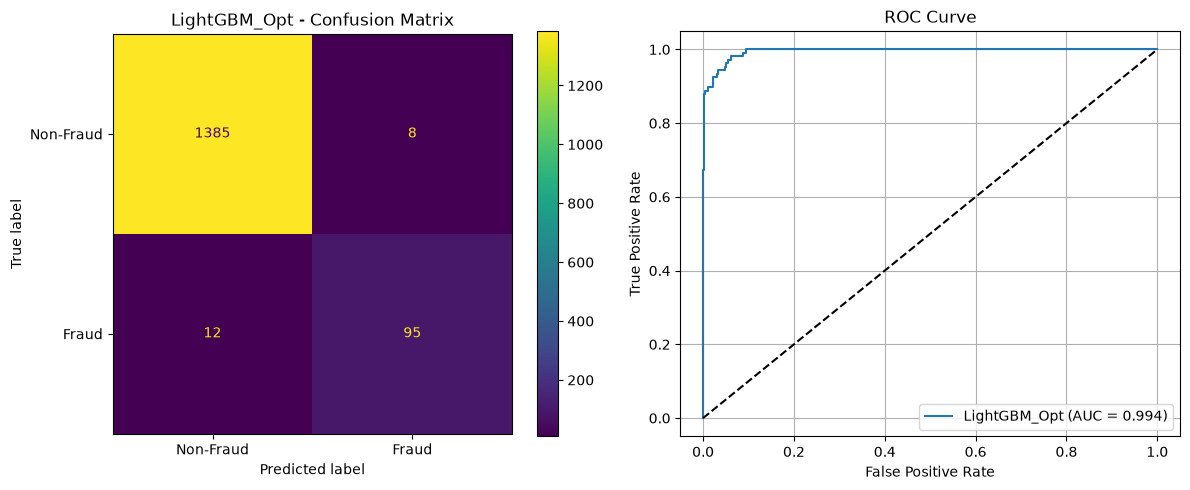

✅ Evaluation plots saved to ../models/evaluation_plots.png


In [ ]:
# Model Evaluation and Visualizations
print("\n" + "=" * 60)
print("MODEL EVALUATION & VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred_best = best_model.predict(X_val_processed)
cm = confusion_matrix(y_val, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Non-Fraud', 'Fraud']).plot(ax=axes[0])
axes[0].set_title(f'{best_model_name} - Confusion Matrix')

y_pred_proba_best = best_model.predict_proba(X_val_processed)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_pred_proba_best)
roc_auc = roc_auc_score(y_val, y_pred_proba_best)

axes[1].plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../models/evaluation_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Evaluation plots saved to ../models/evaluation_plots.png")


PHASE 4: FINAL MODEL TESTING
⚠️  IMPORTANT: Test set has been untouched until now
   Test set size: 1500
   Test fraud rate: 5.93%

📊 Test Set Performance:

LightGBM_Opt_Test:
  Accuracy: 0.9940
  Precision: 0.9255
  Recall: 0.9775
  F1 Score: 0.9508
  ROC-AUC: 0.9987
  PR-AUC: 0.9814


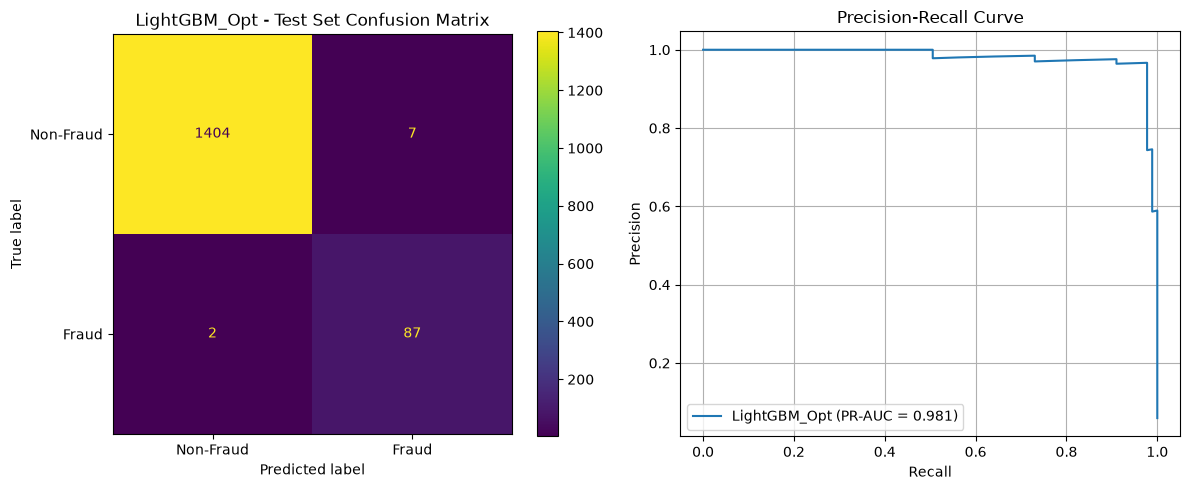


✅ Test set evaluation complete
✅ Performance certificate saved


In [11]:
# Final Model Testing (Test Set)
print("\n" + "=" * 60)
print("PHASE 4: FINAL MODEL TESTING")
print("=" * 60)

print("⚠️  IMPORTANT: Test set has been untouched until now")
print(f"   Test set size: {X_test_processed.shape[0]}")
print(f"   Test fraud rate: {y_test.mean()*100:.2f}%\n")

y_pred_test = best_model.predict(X_test_processed)
y_pred_proba_test = best_model.predict_proba(X_test_processed)[:, 1]

test_metrics = evaluate_model(y_test, y_pred_test, y_pred_proba_test, f"{best_model_name}_Test")

print("📊 Test Set Performance:")
print_metrics(test_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_test = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm_test, display_labels=['Non-Fraud', 'Fraud']).plot(ax=axes[0])
axes[0].set_title(f'{best_model_name} - Test Set Confusion Matrix')

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_test)
pr_auc = average_precision_score(y_test, y_pred_proba_test)

axes[1].plot(recall, precision, label=f'{best_model_name} (PR-AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../models/test_evaluation_plots.png', dpi=300, bbox_inches='tight')
plt.show()

performance_certificate = {
    'model_name': best_model_name,
    'test_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'test_set_size': len(X_test_processed),
    'test_fraud_rate': float(y_test.mean()),
    'accuracy': test_metrics['accuracy'],
    'precision': test_metrics['precision'],
    'recall': test_metrics['recall'],
    'f1_score': test_metrics['f1'],
    'roc_auc': test_metrics['roc_auc'],
    'pr_auc': test_metrics['pr_auc'],
    'confusion_matrix': cm_test.tolist()
}

with open('../models/performance_certificate.json', 'w') as f:
    json.dump(performance_certificate, f, indent=2)

print("\n✅ Test set evaluation complete")
print("✅ Performance certificate saved")


 MODEL INTERPRETATION

🔍 Generating SHAP explanations...


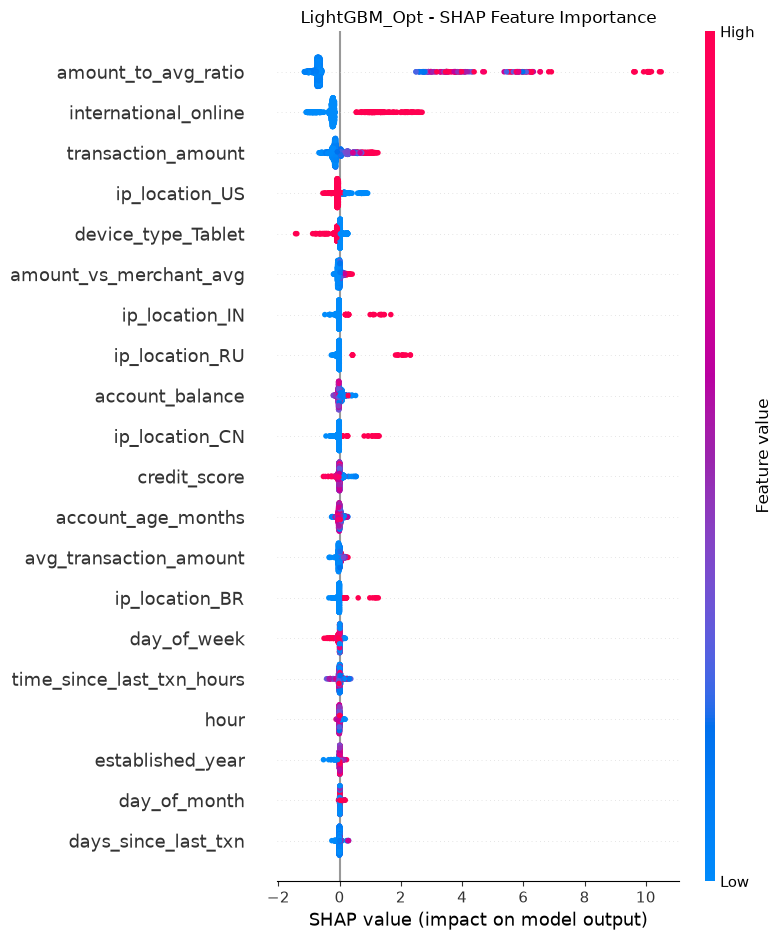

✅ SHAP explanations generated


In [12]:

# Model Interpretation
print("\n" + "=" * 60)
print(" MODEL INTERPRETATION")
print("=" * 60)

try:
    import shap
    
    print("\n🔍 Generating SHAP explanations...")
    explainer = shap.TreeExplainer(best_model)
    
    X_sample = X_val_processed[:min(1000, len(X_val_processed))]
    shap_values = explainer.shap_values(X_sample)
    
    # Get feature names after preprocessing
    feature_names_after_preprocessing = []
    for name, transformer, features in preprocessor.transformers_:
        if name == 'num':
            feature_names_after_preprocessing.extend(features)
        elif name == 'ord':
            feature_names_after_preprocessing.extend(features)
        elif name == 'nom':
            # Get one-hot encoded feature names
            encoder = transformer.named_steps['onehot']
            feature_names_after_preprocessing.extend(encoder.get_feature_names_out(features))
        elif name == 'bin':
            feature_names_after_preprocessing.extend(features)
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names_after_preprocessing, show=False)
    plt.title(f'{best_model_name} - SHAP Feature Importance')
    plt.tight_layout()
    plt.savefig('../models/shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ SHAP explanations generated")
    
except ImportError:
    print("⚠️  SHAP not installed")
except Exception as e:
    print(f"⚠️  SHAP error: {e}")

In [ ]:
# Model Deployment Preparation
print("\n" + "=" * 60)
print("MODEL DEPLOYMENT PREPARATION")
print("=" * 60)

print("\n💾 Serializing model...")
joblib.dump(best_model, '../models/fraud_model.joblib')
joblib.dump(preprocessor, '../models/preprocessor.joblib')
joblib.dump(selector, '../models/selector.joblib')

# Model metadata
model_metadata = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'version': '1.0.0',
    'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'performance_metrics': test_metrics,
    'framework': 'scikit-learn'
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("✅ Model saved")


PHASE 6: MODEL DEPLOYMENT PREPARATION

💾 Serializing model...
✅ Model saved


In [14]:
# Final Summary
print("\n" + "=" * 60)
print("PROJECT COMPLETE - SUMMARY")
print("=" * 60)

print("\n📊 Final Performance Summary:")
print(f"   Best Model: {best_model_name}")
print(f"   Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"   Test Precision: {test_metrics['precision']:.4f}")
print(f"   Test Recall: {test_metrics['recall']:.4f}")
print(f"   Test F1-Score: {test_metrics['f1']:.4f}")
print(f"   Test ROC-AUC: {test_metrics['roc_auc']:.4f}")

print("\n📁 Files Created:")
print("   Models: fraud_model.joblib, preprocessor.joblib, selector.joblib")
print("   Results: baseline_results.csv, optimized_results.csv")
print("   Plots: evaluation_plots.png, test_evaluation_plots.png, shap_summary.png")
print("   Docs: model_metadata.json, performance_certificate.json")

print("\n✅ All phases complete and ready for deployment")


PROJECT COMPLETE - SUMMARY

📊 Final Performance Summary:
   Best Model: LightGBM_Opt
   Test Accuracy: 0.9940
   Test Precision: 0.9255
   Test Recall: 0.9775
   Test F1-Score: 0.9508
   Test ROC-AUC: 0.9987

📁 Files Created:
   Models: fraud_model.joblib, preprocessor.joblib, selector.joblib
   Results: baseline_results.csv, optimized_results.csv
   Plots: evaluation_plots.png, test_evaluation_plots.png, shap_summary.png
   Docs: model_metadata.json, performance_certificate.json

✅ All phases complete and ready for deployment
